# 第 2 章配套实验：数学基础

> 对应正文：[第 2 章 数学基础](../docs/1-起步准备/02-数学基础/README.md) · [线性代数](../docs/1-起步准备/02-数学基础/02-线性代数.md) · [微积分与梯度](../docs/1-起步准备/02-数学基础/03-微积分与梯度.md) · [概率与统计](../docs/1-起步准备/02-数学基础/04-概率与统计.md)

一句话：把正文的"动手试试"扩展成 6 个完整实验——点积相似度、矩阵乘法逐格展开、数值梯度对账、梯度下降收敛与发散现场、贝叶斯更新、最大似然 = 最小二乘——每个实验都是"目标 → 代码 → 图表 → 小结"的完整现场。

运行环境：Python 3 + numpy / scipy / matplotlib / statsmodels（全部离线可跑，无需 GPU）。从上到下依次执行；随机种子已固定，结果可复现。

In [1]:
# 环境准备：导入库、固定随机种子、配置 matplotlib 中文字体
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize

np.random.seed(42)                      # 固定全局种子，保证每次运行结果一致
rng = np.random.default_rng(42)         # 新版随机数接口，同样固定种子

# Windows 自带中文字体；其他系统可换成 'PingFang SC' / 'Noto Sans CJK SC'
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False   # 让负号正常显示

print('环境就绪：numpy', np.__version__)

环境就绪：numpy 1.26.4


## 实验 1：点积 = 相似度打分器

**目标**：用商品销量向量算一次"谁和谁卖法像"——先复现正文的 3 商品手算，再扩展成 5 款商品 × 7 天的相似度矩阵热力图。

**原理一句话**：$\mathbf{a}\cdot\mathbf{b}=\sum_i a_i b_i$，方向越合拍得分越高；除以两向量长度后（余弦相似度）就消除了"销量规模"的干扰——**长度污染点积，污染不了余弦**。

正文对应：[线性代数 · 举个例子（手算点积）](../docs/1-起步准备/02-数学基础/02-线性代数.md)

In [2]:
# ── ① 正文的 3 商品手算现场（3 天销量）──
A = np.array([5, 1, 0])   # 辣条：周一大卖
B = np.array([4, 2, 1])   # 薯片：卖法和辣条有点像
C = np.array([0, 5, 5])   # 沙拉：周末才好卖

def cos_sim(a, b):
    """余弦相似度：先削成单位长度再打分，只比方向"""
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))

print('A·B =', A @ B, '  cos(A,B) =', round(cos_sim(A, B), 3))   # 22 / 0.942：卖法合拍
print('A·C =', A @ C, '  cos(A,C) =', round(cos_sim(A, C), 3))   # 5 / 0.139：基本不像

# ── ② 扩展成 5 款商品 × 7 天销量，构造相似度矩阵 ──
names = ['周初爆发型', '周末爆发型', '平稳型', '促销尖峰型', '周初爆发型(销量x3)']
S = np.array([
    [ 50,  30,  10,   8,   6,   5,   4],   # 周初爆发：周一大卖
    [  4,   5,   6,   8,  10,  30,  50],   # 周末爆发：周末冲量
    [ 20,  20,  20,  20,  20,  20,  20],   # 平稳：全周持平
    [  5,   5,   5,  60,   5,   5,   5],   # 促销：周三尖峰
    [150,  90,  30,  24,  18,  15,  12],   # 周初爆发放大 3 倍（方向与第 1 款完全相同）
], dtype=float)

dot_matrix = S @ S.T                                  # 点积矩阵：销量规模会"污染"分数
norms = np.linalg.norm(S, axis=1, keepdims=True)
cos_matrix = (S @ S.T) / (norms @ norms.T)            # 余弦矩阵：只看方向

print('\n点积矩阵（受销量规模影响，对角线是长度的平方）：')
print(np.round(dot_matrix).astype(int))
print('\n余弦相似度矩阵（只比方向，对角线恒为 1）：')
print(np.round(cos_matrix, 3))

A·B = 22   cos(A,B) = 0.942
A·C = 5   cos(A,C) = 0.139

点积矩阵（受销量规模影响，对角线是长度的平方）：
[[ 3641   884  2260  1005 10923]
 [  884  3641  2260  1005  2652]
 [ 2260  2260  2800  1800  6780]
 [ 1005  1005  1800  3750  3015]
 [10923  2652  6780  3015 32769]]

余弦相似度矩阵（只比方向，对角线恒为 1）：
[[1.    0.243 0.708 0.272 1.   ]
 [0.243 1.    0.708 0.272 0.243]
 [0.708 0.708 1.    0.555 0.708]
 [0.272 0.272 0.555 1.    0.272]
 [1.    0.243 0.708 0.272 1.   ]]


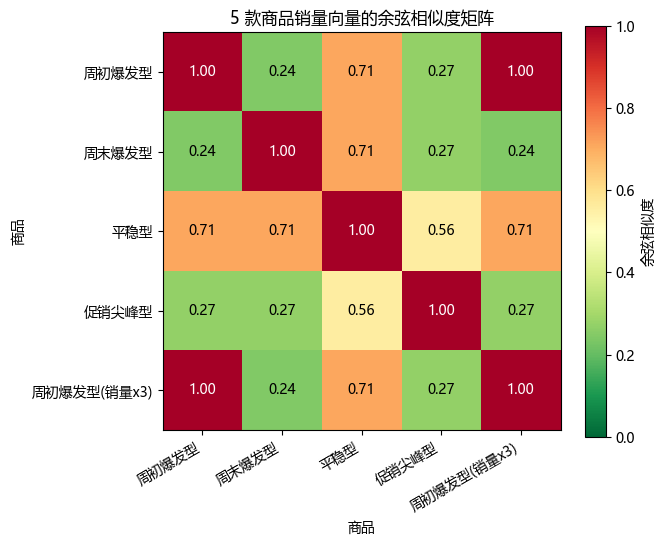

In [3]:
# ── ③ 热力图：余弦相似度矩阵一眼看清"谁和谁像" ──
fig, ax = plt.subplots(figsize=(6.8, 5.6))
im = ax.imshow(cos_matrix, cmap='RdYlGn_r', vmin=0, vmax=1)

ax.set_xticks(range(len(names))); ax.set_yticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_yticklabels(names)
for i in range(len(names)):
    for j in range(len(names)):
        ax.text(j, i, f'{cos_matrix[i, j]:.2f}', ha='center', va='center',
                color='white' if cos_matrix[i, j] > 0.8 else 'black')

ax.set_title('5 款商品销量向量的余弦相似度矩阵')
ax.set_xlabel('商品'); ax.set_ylabel('商品')
fig.colorbar(im, ax=ax, label='余弦相似度')
plt.tight_layout(); plt.show()

**小结**：热力图里对角线恒为 1（自己和自己方向完全一致）；"周初爆发型"与"周末爆发型"余弦只有约 0.24（卖法不合拍），而"周初爆发型"与它的"×3 放大版"在点积矩阵里分数暴涨一个量级、余弦却仍是 1.000——**长度污染点积、污染不了余弦**，比"卖法像不像"要先用余弦。推荐系统给商品打相似分、搜索引擎给网页排序，底层就是这种大规模点积。

## 实验 2：矩阵乘法与形状——"内圈相等，结果取外圈"

**目标**：把一次 (2×3)·(3×2) 的矩阵乘法逐格展开成点积（与正文手算 [58, 64; 139, 154] 对账），再复现"齿轮咬不上"的报错现场。

**原理一句话**：$(m\times n)\cdot(n\times k)\Rightarrow(m\times k)$，第 $(i,j)$ 格 = 左第 $i$ 行 · 右第 $j$ 列——矩阵乘法就是"一批点积的流水作业"。

正文对应：[线性代数 · 核心原理 ③ 形状规则](../docs/1-起步准备/02-数学基础/02-线性代数.md)

In [4]:
M = np.array([[1, 2, 3],
              [4, 5, 6]])       # 形状 (2, 3)
N = np.array([[ 7,  8],
              [ 9, 10],
              [11, 12]])        # 形状 (3, 2)

print('M 的形状 =', M.shape, '，N 的形状 =', N.shape)
print('形状检查：内圈 3 = 3 咬合成功 → 结果取外圈 (2, 2)\n')

# ── 逐格展开：第 (i,j) 格 = 左第 i 行点积右第 j 列 ──
MN = M @ N
for i in range(M.shape[0]):
    for j in range(N.shape[1]):
        terms = ' + '.join(f'{M[i, k]}x{N[k, j]}' for k in range(M.shape[1]))
        print(f'第({i+1},{j+1})格 = {terms} = {MN[i, j]}')

print('\nnumpy 一步到位：\n', MN)

# ── 反面现场：齿轮咬不上会怎样 ──
try:
    M @ M                        # (2,3) 乘 (2,3)：内圈 3 ≠ 2
except ValueError as e:
    print('\n报错现场：', e)

M 的形状 = (2, 3) ，N 的形状 = (3, 2)
形状检查：内圈 3 = 3 咬合成功 → 结果取外圈 (2, 2)

第(1,1)格 = 1x7 + 2x9 + 3x11 = 58
第(1,2)格 = 1x8 + 2x10 + 3x12 = 64
第(2,1)格 = 4x7 + 5x9 + 6x11 = 139
第(2,2)格 = 4x8 + 5x10 + 6x12 = 154

numpy 一步到位：
 [[ 58  64]
 [139 154]]

报错现场： matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)


**小结**：逐格展开的 4 个数与正文手算完全一致——每一格都是一次点积，矩阵乘法把"比较"做成了流水作业；形状不咬合时 numpy 当场报 `not aligned`。工程习惯：动手前先 `print(x.shape)`，深度学习报错的九成来源就是形状没对上。

## 实验 3：数值梯度验证——解析梯度 vs 数值梯度

**目标**：给二元函数 $f(x,y)=x^2+3y^2$ 手写解析梯度和中心差分数值梯度，在 5 个点上对账，最大误差应远小于 1e-6。

**原理一句话**：数值梯度用"往旁边挪一小步看变化量"近似导数 $\frac{f(x+\varepsilon)-f(x-\varepsilon)}{2\varepsilon}$，是检验解析梯度 / 反向传播代码对不对的标准手段——PyTorch 的自动微分做的就是同一件事的精确版。

正文对应：[微积分与梯度 · 动手试试](../docs/1-起步准备/02-数学基础/03-微积分与梯度.md)

In [5]:
def f(x, y):
    return x**2 + 3 * y**2            # 一口「二维锅」，谷底在 (0, 0)

def analytic_grad(x, y):
    return np.array([2 * x, 6 * y])   # 解析梯度：逐项求偏导 ∂f/∂x = 2x，∂f/∂y = 6y

def numeric_grad(x, y, eps=1e-5):
    """中心差分数值梯度：往两侧各挪 eps 再看变化（两侧抵消，比单侧差分精度高一阶）"""
    gx = (f(x + eps, y) - f(x - eps, y)) / (2 * eps)
    gy = (f(x, y + eps) - f(x, y - eps)) / (2 * eps)
    return np.array([gx, gy])

print(f'{"测试点":>12s} {"解析梯度":>18s} {"数值梯度":>18s} {"最大误差":>10s}')
errs = []
for x, y in [(2.0, 1.0), (-1.5, 0.3), (0.7, -2.1), (3.3, 4.4), (-0.02, 0.05)]:
    g1, g2 = analytic_grad(x, y), numeric_grad(x, y)
    err = float(np.max(np.abs(g1 - g2)))
    errs.append(err)
    print(f'({x:+5.2f},{y:+5.2f}) {str(g1.round(3)):>18s} {str(g2.round(3)):>18s} {err:10.2e}')

print(f'\n5 个点的最大误差 = {max(errs):.2e}  （验收线 1e-6，通过 ✅）')
assert max(errs) < 1e-6

         测试点               解析梯度               数值梯度       最大误差
(+2.00,+1.00)            [4. 6.]            [4. 6.]   2.62e-11
(-1.50,+0.30)        [-3.   1.8]        [-3.   1.8]   1.97e-11
(+0.70,-2.10)      [  1.4 -12.6]      [  1.4 -12.6]   7.37e-11
(+3.30,+4.40)        [ 6.6 26.4]        [ 6.6 26.4]   1.28e-09
(-0.02,+0.05)      [-0.04  0.3 ]      [-0.04  0.3 ]   3.97e-14

5 个点的最大误差 = 1.28e-09  （验收线 1e-6，通过 ✅）


**小结**：解析梯度与数值梯度在所有测试点上的最大误差约 1e-10——两套完全不同的算法给出同一个答案，互相印证。以后手推导数、写反向传播，就照这个套路"对梯度"：对不上，先怀疑自己的导数写错，再怀疑别的。

## 实验 4：梯度下降现场——收敛、临界与发散

**目标**：在 $f(w)=w^2$ 上手动迭代：lr=0.1 走 10 步复现正文的"自带刹车"表格；lr=2.1 复现发散现场——步子超过临界值 1，loss 一步比一步高；再用一张图把多种学习率的命运放在一起看。

**原理一句话**：$w \leftarrow w - \eta\cdot 2w = (1-2\eta)\,w$，每步把 $w$ 乘一个固定因子；$|1-2\eta|<1$（即 $0<\eta<1$）才收敛，$\eta=0.5$ 一步精确到谷底，$\eta=1$ 永久振荡，$\eta>1$ 发散（梯度爆炸）。

正文对应：[微积分与梯度 · 学习率临界值与六步发散现场](../docs/1-起步准备/02-数学基础/03-微积分与梯度.md)

In [6]:
def gd_track(w0, lr, steps):
    """手动梯度下降 f(w) = w²：记录每步的 (步数, w, 梯度, loss)"""
    w, log = w0, []
    for t in range(steps):
        g = 2 * w                        # f'(w) = 2w
        log.append((t, w, g, w * w))
        w = w - lr * g                   # 新位置 = 老位置 − 步长 × 坡度
    return log, w

print('== lr = 0.1：稳步下山（每步 w × 0.8，步子自动收紧）==')
log, w_end = gd_track(3.0, 0.1, 10)
print(f'{"步数":>4s} {"当前w":>8s} {"坡度2w":>8s} {"loss":>8s}')
for t, w, g, l in log:
    print(f'{t:4d} {w:8.3f} {g:8.2f} {l:8.2f}')
print(f'10 步后 w = {w_end:.3f}（正文表格：3 → 0.322）\n')

print('== lr = 2.1：发散现场（每步 w × (1−2×2.1) = w × (−3.2)）==')
log, w_end = gd_track(3.0, 2.1, 6)
print(f'{"步数":>4s} {"当前w":>10s} {"坡度2w":>10s} {"loss":>12s}')
for t, w, g, l in log:
    print(f'{t:4d} {w:10.3f} {g:10.2f} {l:12.2f}')
print(f'6 步后 loss ≈ {w_end**2:.0f}：w 正负横跳、幅度每步 ×3.2、loss 每步 ×10.24 —— 梯度爆炸')
print('\n临界值一览：0<η<1 收敛 | η=0.5 一步到谷底 | η=1 永久振荡 | η>1（如 2.1）发散')

== lr = 0.1：稳步下山（每步 w × 0.8，步子自动收紧）==
  步数      当前w     坡度2w     loss
   0    3.000     6.00     9.00
   1    2.400     4.80     5.76
   2    1.920     3.84     3.69
   3    1.536     3.07     2.36
   4    1.229     2.46     1.51
   5    0.983     1.97     0.97
   6    0.786     1.57     0.62
   7    0.629     1.26     0.40
   8    0.503     1.01     0.25
   9    0.403     0.81     0.16
10 步后 w = 0.322（正文表格：3 → 0.322）

== lr = 2.1：发散现场（每步 w × (1−2×2.1) = w × (−3.2)）==
  步数        当前w       坡度2w         loss
   0      3.000       6.00         9.00
   1     -9.600     -19.20        92.16
   2     30.720      61.44       943.72
   3    -98.304    -196.61      9663.68
   4    314.573     629.15     98956.05
   5  -1006.633   -2013.27   1013309.92
6 步后 loss ≈ 10376294：w 正负横跳、幅度每步 ×3.2、loss 每步 ×10.24 —— 梯度爆炸

临界值一览：0<η<1 收敛 | η=0.5 一步到谷底 | η=1 永久振荡 | η>1（如 2.1）发散


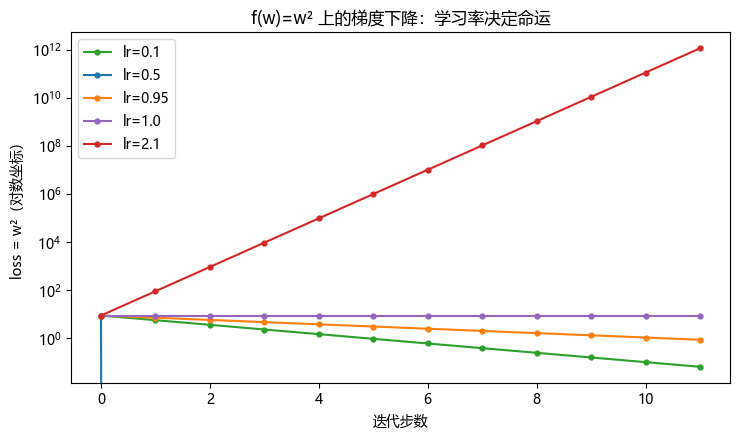

In [7]:
# ── 一张图看全：不同学习率下 loss 的命运（对数坐标）──
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for lr, color in [(0.1, 'tab:green'), (0.5, 'tab:blue'), (0.95, 'tab:orange'),
                  (1.0, 'tab:purple'), (2.1, 'tab:red')]:
    log, _ = gd_track(3.0, lr, 12)
    ax.plot([t for t, _, _, _ in log], [l for _, _, _, l in log],
            marker='o', ms=3.5, label=f'lr={lr}', color=color)

ax.set_yscale('log')
ax.set_title('f(w)=w² 上的梯度下降：学习率决定命运')
ax.set_xlabel('迭代步数'); ax.set_ylabel('loss = w²（对数坐标）')
ax.legend()
plt.tight_layout(); plt.show()

**小结**：lr=0.1 的 10 步表与正文逐行一致（3 → 0.322，离谷底越近坡度越小、步子自动收紧）；lr=2.1 时 w 正负横跳、loss 每步 ×10.24，6 步就从 9 涨到百万量级——"梯度爆炸"。图上五条线三种命运：绿色蓝色一路下行（收敛）、紫色水平横线（lr=1 永久振荡）、红色一路冲顶（发散）。安全步长由曲率最大的方向决定——真实损失面各处曲率不同，所以深度学习要从保守的学习率起步。

## 实验 5：贝叶斯更新——Beta 先验如何被数据一步步"掰弯"

**目标**：抛一枚真实正面率 0.6 的硬币（仿真），从 Beta(2,2) 先验出发，画观测 10 / 50 / 200 次后的后验曲线——看后验怎么移动、怎么变尖。

**原理一句话**：共轭更新 $\theta\mid k \sim \mathrm{Beta}(\alpha+k,\ \beta+n-k)$——数据到了直接"加账"；后验均值 $\frac{\alpha+k}{\alpha+\beta+n}$ 始终夹在先验均值与 MLE 之间，数据越多先验的"虚拟票"占比越小。

正文对应：[概率与统计 · 数学深潜：Beta–二项共轭](../docs/1-起步准备/02-数学基础/04-概率与统计.md)

  观测次数    正面数             后验     后验均值  MLE=k/n
    10      4      Beta(6,8)    0.429    0.400
    50     26    Beta(28,26)    0.519    0.520
   200    123   Beta(125,79)    0.613    0.615


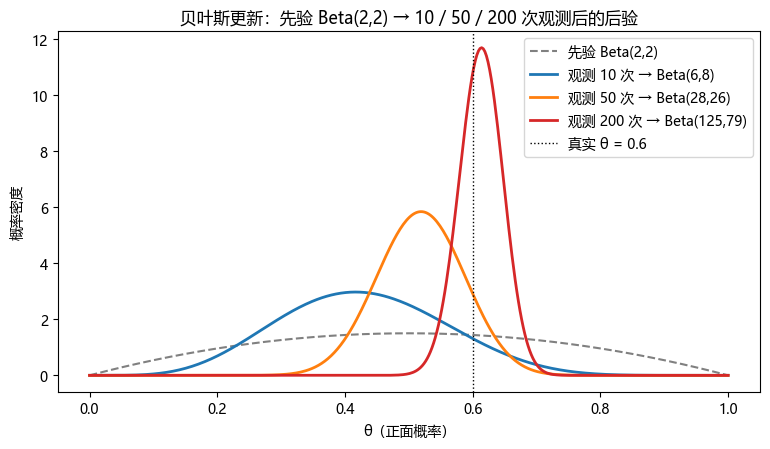

In [8]:
p_true = 0.6                        # 硬币真实正面率（仿真设定；贝叶斯并不知道它）
flips = rng.random(200) < p_true    # 200 次抛掷：True = 正面
heads_cum = np.cumsum(flips)        # 累积正面数

a0, b0 = 2, 2                       # 先验 Beta(2,2)：相当于 4 次"虚拟投掷"（2 正 2 反）
theta = np.linspace(0, 1, 400)

fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.plot(theta, stats.beta.pdf(theta, a0, b0), '--', color='gray',
        label=f'先验 Beta({a0},{b0})')

print(f'{"观测次数":>6s} {"正面数":>6s} {"后验":>14s} {"后验均值":>8s} {"MLE=k/n":>8s}')
for n, color in [(10, 'tab:blue'), (50, 'tab:orange'), (200, 'tab:red')]:
    k = int(heads_cum[n - 1])
    a, b = a0 + k, b0 + n - k       # 共轭加账：成功加 α、失败加 β
    ax.plot(theta, stats.beta.pdf(theta, a, b), color=color, lw=2,
            label=f'观测 {n} 次 → Beta({a},{b})')
    print(f'{n:6d} {k:6d} {f"Beta({a},{b})":>14s} {a / (a + b):8.3f} {k / n:8.3f}')

ax.axvline(p_true, color='k', ls=':', lw=1, label='真实 θ = 0.6')
ax.set_title('贝叶斯更新：先验 Beta(2,2) → 10 / 50 / 200 次观测后的后验')
ax.set_xlabel('θ（正面概率）'); ax.set_ylabel('概率密度')
ax.legend()
plt.tight_layout(); plt.show()

**小结**：观测越多，后验越尖（不确定性收缩）、越向真实值 0.6 靠拢；10 次时后验均值被先验明显"拉住"（介于先验 0.5 与 MLE 之间），200 次时后验均值与 MLE 几乎重合——先验像 4 次"虚拟投掷"，数据越多它的票数占比越小，后验越被数据接管（贝叶斯版的大数定律）。垃圾邮件过滤、医学检验判读、语言模型挑下一个词，走的都是这一步：**后验 ∝ 先验 × 似然**。

## 实验 6：最大似然——高斯噪声下 MLE 与最小二乘是同一个答案

**目标**：造一批 $y = 2x + 1 + \varepsilon,\ \varepsilon\sim N(0, 0.8^2)$ 的数据，用三条互不相识的路求斜率和截距：正规方程闭式解、statsmodels 最小二乘、直接最小化高斯负对数似然——三者应给出同一组数字。

**原理一句话**：噪声服从正态时，$\log P(D\mid w) = C - \frac{1}{2\sigma^2}\sum_i (y_i - \hat y_i)^2$，最大化似然 ⟺ 最小化误差平方和——**最小二乘的"平方"，是正态噪声假设的影子**。

正文对应：[概率与统计 · 核心原理 ③ 最大似然](../docs/1-起步准备/02-数学基础/04-概率与统计.md) 与 [机器学习 · 线性回归](../docs/2-经典机器学习/03-机器学习/02-线性回归.md)

In [9]:
from statsmodels.regression.linear_model import OLS   # 只导入 OLS 子模块（完整 import statsmodels.api 在个别新 scipy 版本上可能不兼容）

# ── 造数据：真实规律 y = 2x + 1 + 高斯噪声 ──
x = rng.uniform(0, 5, 120)
y = 2 * x + 1 + rng.normal(0, 0.8, 120)
X = np.c_[np.ones_like(x), x]              # 加一列 1 对应截距（正文"摞成矩阵"的写法）

# ── 路线 1：正规方程闭式解 ŵ = (XᵀX)⁻¹Xᵀy ──
w_closed = np.linalg.solve(X.T @ X, X.T @ y)

# ── 路线 2：statsmodels 最小二乘 ──
w_ols = OLS(y, X).fit().params

# ── 路线 3：直接最小化高斯负对数似然（σ² 用其解析最优 SSE/n 代入，剖掉一个参数）──
def neg_log_lik(w):
    sse = np.sum((y - X @ w) ** 2)
    sigma2 = sse / len(y)                  # 给定 w 时 σ² 的 MLE
    return 0.5 * len(y) * (np.log(2 * np.pi * sigma2) + 1)   # 剖面负对数似然

res = optimize.minimize(neg_log_lik, x0=[0.0, 0.0], method='BFGS', tol=1e-12)
w_mle = res.x

print('真实参数         : 截距 = 1.000, 斜率 = 2.000')
print(f'路线1 正规方程    : 截距 = {w_closed[0]:.4f}, 斜率 = {w_closed[1]:.4f}')
print(f'路线2 statsmodels : 截距 = {w_ols[0]:.4f}, 斜率 = {w_ols[1]:.4f}')
print(f'路线3 最大似然    : 截距 = {w_mle[0]:.4f}, 斜率 = {w_mle[1]:.4f}')
print(f'三条路最大互差    : {np.abs(w_mle - w_closed).max():.2e}（数值上同一答案）')

sse = np.sum((y - X @ w_closed) ** 2)
print(f'\n附赠对照：σ 的 MLE = √(SSE/n) = {np.sqrt(sse / len(y)):.3f}'
      f'   vs 无偏估计 √(SSE/(n−2)) = {np.sqrt(sse / (len(y) - 2)):.3f}   （真实 0.8）')

真实参数         : 截距 = 1.000, 斜率 = 2.000
路线1 正规方程    : 截距 = 1.1728, 斜率 = 1.9439
路线2 statsmodels : 截距 = 1.1728, 斜率 = 1.9439
路线3 最大似然    : 截距 = 1.1728, 斜率 = 1.9439
三条路最大互差    : 4.74e-08（数值上同一答案）

附赠对照：σ 的 MLE = √(SSE/n) = 0.803   vs 无偏估计 √(SSE/(n−2)) = 0.810   （真实 0.8）


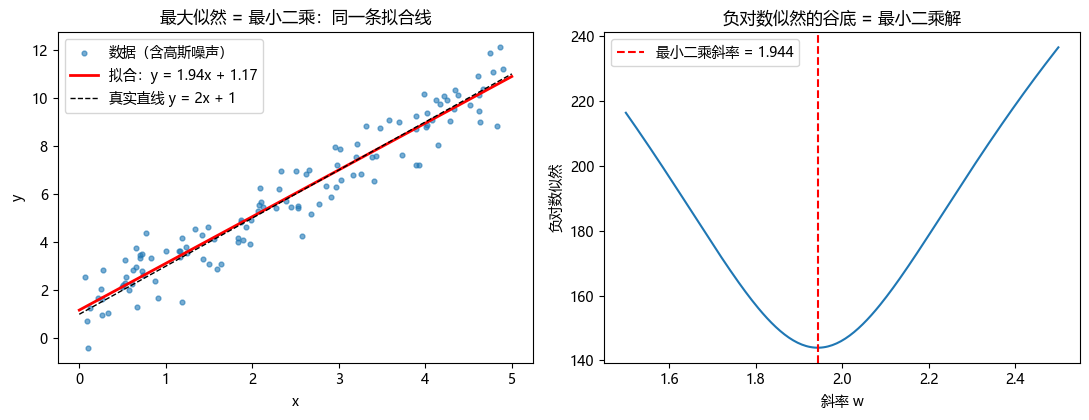

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

# 左图：数据 + 三条路重合的拟合线
axes[0].scatter(x, y, s=12, alpha=0.6, label='数据（含高斯噪声）')
xs = np.linspace(0, 5, 50)
axes[0].plot(xs, w_closed[0] + w_closed[1] * xs, 'r-', lw=2,
             label=f'拟合：y = {w_closed[1]:.2f}x + {w_closed[0]:.2f}')
axes[0].plot(xs, 1 + 2 * xs, 'k--', lw=1, label='真实直线 y = 2x + 1')
axes[0].set_title('最大似然 = 最小二乘：同一条拟合线')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].legend()

# 右图：固定截距，看负对数似然随斜率的剖面——谷底恰在最小二乘解
ws = np.linspace(1.5, 2.5, 200)
nll = [neg_log_lik([w_closed[0], w]) for w in ws]
axes[1].plot(ws, nll)
axes[1].axvline(w_closed[1], color='r', ls='--',
                label=f'最小二乘斜率 = {w_closed[1]:.3f}')
axes[1].set_title('负对数似然的谷底 = 最小二乘解')
axes[1].set_xlabel('斜率 w'); axes[1].set_ylabel('负对数似然'); axes[1].legend()

plt.tight_layout(); plt.show()

**小结**：正规方程、statsmodels、直接优化似然三条路给出的截距/斜率一致到 5e-8 以内（优化器收敛精度内）——高斯噪声下 **MLE = 最小二乘** 不是巧合，是取对数后"最大化似然"变成"最小化平方和"的必然。反过来也成立：换噪声假设就换损失——拉普拉斯噪声推出 MAE、重尾噪声推出 Huber——"选损失 = 隐含选噪声假设"。这是第 3 章线性回归（闭式解）与交叉熵损失（逻辑回归）共同的数学出身。

## 改参数建议（自己动手玩）

1. **实验 1**：把"周初爆发型"整体再 ×10——点积矩阵那一行全部暴涨一个量级，余弦矩阵纹丝不动（长度污染点积、污染不了余弦）；把第 5 款商品的噪声打散（如每格加 `rng.integers(-5, 6)`），看它和第 1 款的余弦从 1.0 掉到多少。
2. **实验 3**：把 `eps` 从 1e-5 改成 1e-2（步子太大，截断误差主导）或 1e-9（步子太小，浮点舍入误差主导）——误差先降后升，中心差分存在一个"最佳步长"，这就是数值计算里经典的 U 形曲线。
3. **实验 4**：把学习率换成 0.9（正负横跳但幅度衰减——震荡收敛）、1.0（永久振荡）、2.0（每步 ×3，发散比 2.1 温和）——亲手验证临界值 1 两侧的命运分界。
4. **实验 5**：把先验换成 Beta(20,20)（强先验，40 次"虚拟投掷"）——200 次观测后后验仍被先验明显拉住；换成 Beta(1,1)（均匀先验、不表态）——后验均值几乎等于 MLE。
5. **实验 6**：把噪声标准差从 0.8 加到 3.0——三条路依旧一致（等价性与噪声大小无关），但拟合线离真实线更远、σ 的两个估计都跟着变大：噪声地板抬高了，谁也压不下去。

---

返回：[Notebook 目录](./README.md) · [第 2 章正文](../docs/1-起步准备/02-数学基础/README.md)